# 1

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, auc,
    classification_report
)
from numpy import argmax

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    random_state=1
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=2)

In [6]:
model = LogisticRegression().fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]

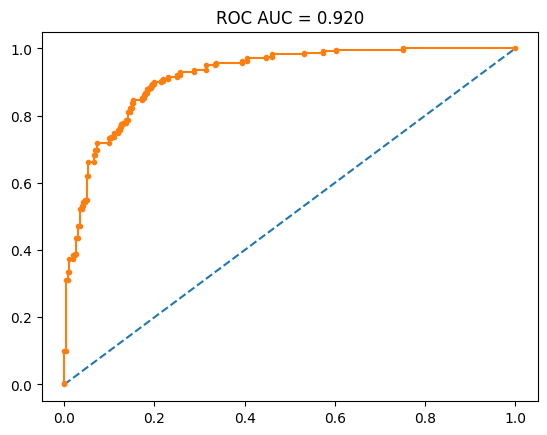

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot([0, 1], [0, 1], '--')
plt.plot(fpr, tpr, marker='.')
plt.title(f'ROC AUC = {roc_auc_score(y_test, y_proba):.3f}')
plt.show()

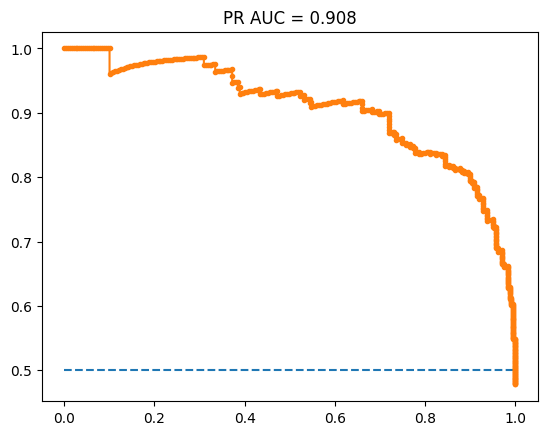

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
no_skill = y.mean()
plt.plot([0, 1], [no_skill, no_skill], '--')
plt.plot(recall, precision, marker='.')
plt.title(f'PR AUC = {auc(recall, precision):.3f}')
plt.show()

In [9]:
y_pred = model.predict(X_test)
print('Default threshold (0.5):\n',
      classification_report(y_test, y_pred))

Default threshold (0.5):
               precision    recall  f1-score   support

           0       0.87      0.82      0.84       261
           1       0.81      0.87      0.84       239

    accuracy                           0.84       500
   macro avg       0.84      0.84      0.84       500
weighted avg       0.84      0.84      0.84       500



In [10]:
f1_scores = (2 * precision * recall) / (precision + recall)
ix = argmax(f1_scores)
best_thresh = _[ix]
print(f'\nBest threshold = {best_thresh:.3f}, F1 = {f1_scores[ix]:.3f}')


Best threshold = 0.444, F1 = 0.850


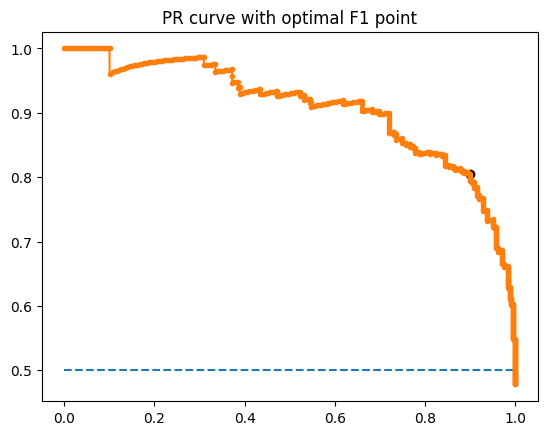

In [11]:
plt.figure()
plt.plot([0, 1], [no_skill, no_skill], '--')
plt.plot(recall, precision, marker='.')
plt.scatter(recall[ix], precision[ix], color='black')
plt.title('PR curve with optimal F1 point')
plt.show()

In [12]:
y_pred_opt = (y_proba > best_thresh).astype(int)
print('\nUsing optimal threshold:\n',
      classification_report(y_test, y_pred_opt))


Using optimal threshold:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84       261
           1       0.80      0.90      0.85       239

    accuracy                           0.85       500
   macro avg       0.85      0.85      0.85       500
weighted avg       0.85      0.85      0.85       500

